In [47]:
import helpers.Create_Target_Variable as Create_Target_Variable
import helpers.create_team_tendency_features as create_team_tendency_features
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

## Data Preparation

### Data Acquisition

In [48]:
# gather data
plays_df = pd.DataFrame()

plays_files = ['2017_plays.csv',
               '2018_plays.csv',
               '2019_plays.csv',
               '2020_plays.csv',
               '2021_plays.csv',
               '2022_plays.csv',
               '2023_plays.csv',
               '2024_plays.csv',
               '2025_plays.csv'
               ]

for file in plays_files:
    temp_df = pd.read_csv('Classify Plays/' + file)
    plays_df = pd.concat([plays_df, temp_df])

### Data Pre-Processing

In [49]:
# drop rows where PlayStart is null - irrelevant data
plays_df.dropna(subset=['PlayStart'], inplace=True)

# drop sacks and penalty plays - can't classify a play call
plays_df = plays_df[~plays_df['PlayOutcome'].str.contains('sack|penalty', case=False, na=False)]

# remove 'Hall Of Fame' and 'Preseason' games
plays_df = plays_df[~plays_df['Week'].str.contains('Hall Of Fame|Preseason|18|Wild|Conference|Divisional|Super', na=False)]

# remove the 'Week' prefix
plays_df['Week'] = plays_df['Week'].str[-2:].str.strip()
# Convert Week to int
plays_df['Week'] = plays_df['Week'].astype(int)

### Target Variable Creation

In [50]:
# create target variable: play call
plays_df['PlayCall'] = plays_df.apply(Create_Target_Variable.classify_play_call, axis=1)

In [51]:
# drop where play cannot be classified
plays_df.dropna(subset=['PlayCall'], inplace=True)

### Feature Engineering

In [52]:
# map team with possesion to abbreviated name
team_name_map = {
    'Arizona Cardinals': 'ARI',
    'Dallas Cowboys': 'DAL',
    'Houston Texans': 'HOU',
    'Carolina Panthers': 'CAR',
    'Minnesota Vikings': 'MIN',
    'Buffalo Bills': 'BUF',
    'Miami Dolphins': 'MIA',
    'Atlanta Falcons': 'ATL',
    'Washington Commanders': 'WAS',
    'Baltimore Ravens': 'BAL',
    'Jacksonville Jaguars': 'JAX',
    'New England Patriots': 'NE',
    'Chicago Bears': 'CHI',
    'Denver Broncos': 'DEN',
    'New Orleans Saints': 'NO',
    'Cleveland Browns': 'CLE',
    'Green Bay Packers': 'GB',
    'Philadelphia Eagles': 'PHI',
    'Pittsburgh Steelers': 'PIT',
    'New York Giants': 'NYG',
    'Tampa Bay Buccaneers': 'TB',
    'Cincinnati Bengals': 'CIN',
    'Kansas City Chiefs': 'KC',
    'San Francisco 49ers': 'SF',
    'New York Jets': 'NYJ',
    'Tennessee Titans': 'TEN',
    'Los Angeles Rams': 'LAR',
    'Las Vegas Raiders': 'LV',
    'Detroit Lions': 'DET',
    'Indianapolis Colts': 'IND',
    'Los Angeles Chargers': 'LAC',
    'Seattle Seahawks': 'SEA'
}

plays_df['TeamWithPossessionShort'] = plays_df['TeamWithPossession'].map(team_name_map)

In [53]:
### extract data from PlayStart field e.g. "3rd & 1 at LAC 1" ###

# split before and after " at "
temp = plays_df['PlayStart'].str.split(' at ', expand=True)
left = temp[0]   # "3rd & 1"
right = temp[1]  # "LAC 1"

# extract Down and YdsTo1stDown
plays_df['Down'] = left.str.extract(r'(\d+)').astype(int)
plays_df['YdsTo1stDown'] = left.str.extract(r'&\s*(\d+)').astype(int)

# extract Territory and YdPosition
plays_df['Territory'] = right.str.extract(r'([A-Z]+)')
plays_df['YdPosition'] = right.str.extract(r'(\d+)').astype(int)

In [54]:
# convert JAC to JAX and OAK to LV in Territory field
plays_df['Territory'] = plays_df['Territory'].replace({
    'JAC': 'JAX',
    'OAK': 'LV'
})

In [55]:
# calculate yards to enzone
def get_yds_to_endzone(row):
    if row['YdPosition'] == 50:
        return 50
    elif row['Territory'] == row['TeamWithPossessionShort']:
        return row['YdPosition'] + 50
    else:
        return row['YdPosition']

plays_df['YdsToEndzone'] = plays_df.apply(get_yds_to_endzone, axis=1)

In [56]:
# calculate minutes remaining in game as a float
def extract_minutes(time_str):
    # convert mm:ss to float minutes.
    minutes, seconds = time_str.split(":")
    return int(minutes) + int(seconds) / 60

def compute_min_remaining(row):
    # extract the mm:ss at the start of PlayTimeFormation
    time_part = row["PlayTimeFormation"].split()[0]   # e.g., "14:49"
    minutes_left = extract_minutes(time_part)

    quarter = row["Quarter"]

    if quarter == "4th Quarter" or quarter == "Overtime":
        return minutes_left
    elif quarter == "3rd Quarter":
        return minutes_left + 15
    elif quarter == "2nd Quarter":
        return minutes_left + 30
    elif quarter == "1st Quarter":
        return minutes_left + 45
    else:
        return None  # in case of unexpected values

# apply the function to create MinRemaining
plays_df["MinRemaining"] = plays_df.apply(compute_min_remaining, axis=1)

In [58]:
# Calculate global means for fallback (using all seasons data)
global_means = create_team_tendency_features.calculate_season_means(plays_df, season=None)

LEAGUE AVERAGES FOR ALL SEASONS
Run         : 43.87%
Short_Pass  : 51.27%
Long_Pass   :  4.86%



In [59]:
# Add team tendency features for each season
all_seasons_with_features = []

for year in range(2017, 2026):  # 2017-2025
    print(f"\nProcessing {year}...")
    
    # Get current season data
    df_season = plays_df[plays_df['Season'] == year].copy()
    
    # Get previous season data (None for 2017)
    if year == 2017:
        df_previous = None
        print(f"  Using global means (first season)")
    else:
        df_previous = plays_df[plays_df['Season'] == (year - 1)].copy()
        print(f"  Using {year-1} season data for early weeks")
    
    # Add features
    df_with_features = create_team_tendency_features.add_team_tendency_features(
        df_season=df_season,
        df_previous_season=df_previous,
        global_means=global_means,
        team_col='TeamWithPossessionShort'
    )
    
    all_seasons_with_features.append(df_with_features)

# Combine all seasons back together
plays_df = pd.concat(all_seasons_with_features, ignore_index=True)

print(f"Added features to {len(plays_df):,} plays")
print(f"New columns: team_run_pct, team_short_pass_pct, team_long_pass_pct")


Processing 2017...
  Using global means (first season)

Processing 32 teams for season 2017...
Added team tendency features for 32 teams

Processing 2018...
  Using 2017 season data for early weeks

Processing 32 teams for season 2018...
Added team tendency features for 32 teams

Processing 2019...
  Using 2018 season data for early weeks

Processing 32 teams for season 2019...
Added team tendency features for 32 teams

Processing 2020...
  Using 2019 season data for early weeks

Processing 32 teams for season 2020...
Added team tendency features for 32 teams

Processing 2021...
  Using 2020 season data for early weeks

Processing 32 teams for season 2021...
Added team tendency features for 32 teams

Processing 2022...
  Using 2021 season data for early weeks

Processing 32 teams for season 2022...
Added team tendency features for 32 teams

Processing 2023...
  Using 2022 season data for early weeks

Processing 32 teams for season 2023...
Added team tendency features for 32 teams

Pro

In [60]:
print(plays_df.columns)

Index(['Season', 'Week', 'Day', 'Date', 'AwayTeam', 'HomeTeam', 'Quarter',
       'DriveNumber', 'TeamWithPossession', 'IsScoringDrive',
       'PlayNumberInDrive', 'IsScoringPlay', 'PlayOutcome', 'PlayStart',
       'PlayTimeFormation', 'PlayDescription', 'PlayCall',
       'TeamWithPossessionShort', 'Down', 'YdsTo1stDown', 'Territory',
       'YdPosition', 'YdsToEndzone', 'MinRemaining', 'GameId', 'team_run_pct',
       'team_short_pass_pct', 'team_long_pass_pct'],
      dtype='object')


In [61]:
# Add team tendency features for each season
all_seasons_with_features = []

for year in range(2017, 2026):  # 2017-2025
    print(f"\nProcessing {year}...")
    
    # Get current season data
    df_season = plays_df[plays_df['Season'] == year].copy()
    
    # Get previous season data (None for 2017)
    if year == 2017:
        df_previous = None
        print(f"  Using global means (first season)")
    else:
        df_previous = plays_df[plays_df['Season'] == (year - 1)].copy()
        print(f"  Using {year-1} season data for early weeks")
    
    # Add features
    df_with_features = create_team_tendency_features.add_team_tendency_features(
        df_season=df_season,
        df_previous_season=df_previous,
        global_means=global_means,
        team_col='TeamWithPossessionShort'
    )
    
    all_seasons_with_features.append(df_with_features)

# Combine all seasons back together
plays_df = pd.concat(all_seasons_with_features, ignore_index=True)

print(f"Added features to {len(plays_df):,} plays")
print(f"New columns: team_run_pct, team_short_pass_pct, team_long_pass_pct")


Processing 2017...
  Using global means (first season)

Processing 32 teams for season 2017...
Added team tendency features for 32 teams

Processing 2018...
  Using 2017 season data for early weeks

Processing 32 teams for season 2018...
Added team tendency features for 32 teams

Processing 2019...
  Using 2018 season data for early weeks

Processing 32 teams for season 2019...
Added team tendency features for 32 teams

Processing 2020...
  Using 2019 season data for early weeks

Processing 32 teams for season 2020...
Added team tendency features for 32 teams

Processing 2021...
  Using 2020 season data for early weeks

Processing 32 teams for season 2021...
Added team tendency features for 32 teams

Processing 2022...
  Using 2021 season data for early weeks

Processing 32 teams for season 2022...
Added team tendency features for 32 teams

Processing 2023...
  Using 2022 season data for early weeks

Processing 32 teams for season 2023...
Added team tendency features for 32 teams

Pro

## Data Visualization

In [63]:
clean_df = plays_df[["DriveNumber", "PlayCall", "Down", "YdsTo1stDown", "YdsToEndzone", "MinRemaining", "team_run_pct", "team_short_pass_pct", "team_long_pass_pct"]]
print(clean_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285588 entries, 0 to 285587
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DriveNumber          285588 non-null  int64  
 1   PlayCall             285588 non-null  object 
 2   Down                 285588 non-null  int64  
 3   YdsTo1stDown         285588 non-null  int64  
 4   YdsToEndzone         285588 non-null  int64  
 5   MinRemaining         285588 non-null  float64
 6   team_run_pct         285588 non-null  float64
 7   team_short_pass_pct  285588 non-null  float64
 8   team_long_pass_pct   285588 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 19.6+ MB
None


In [64]:
clean_df['PlayCall'].unique()

array(['Short_Pass', 'Run', 'Long_Pass', 'Field_Goal', 'Punt', 'Spike'],
      dtype=object)

In [65]:
# save/create clean_df as a csv in our current directory, if it already exists then update it 
clean_df.to_csv('clean_plays_data.csv', index=False)
print("Data saved to clean_plays_data.csv")

Data saved to clean_plays_data.csv


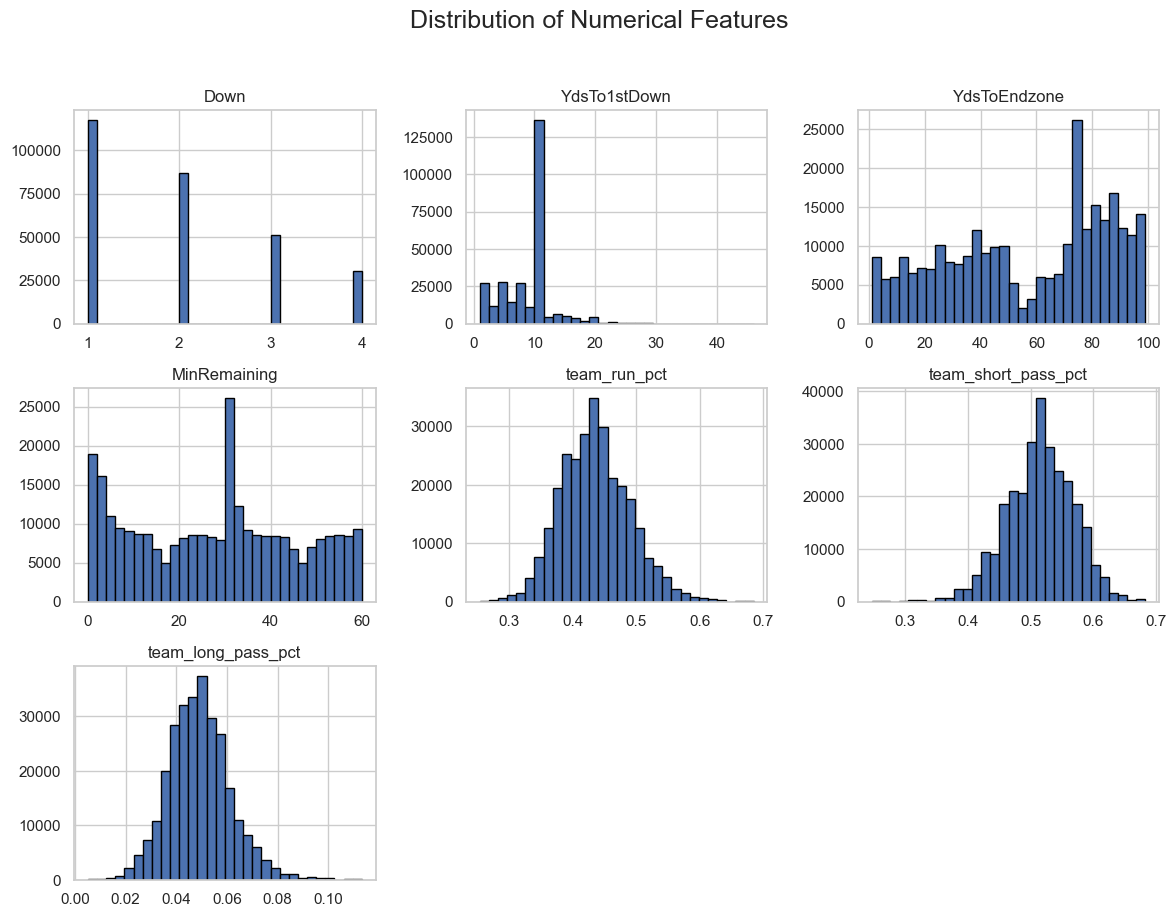

In [66]:
num_cols = ['Down', 'YdsTo1stDown', 'YdsToEndzone', 'MinRemaining',
            'team_run_pct', 'team_short_pass_pct', 'team_long_pass_pct']

clean_df[num_cols].hist(bins=30, figsize=(14,10), edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.show()

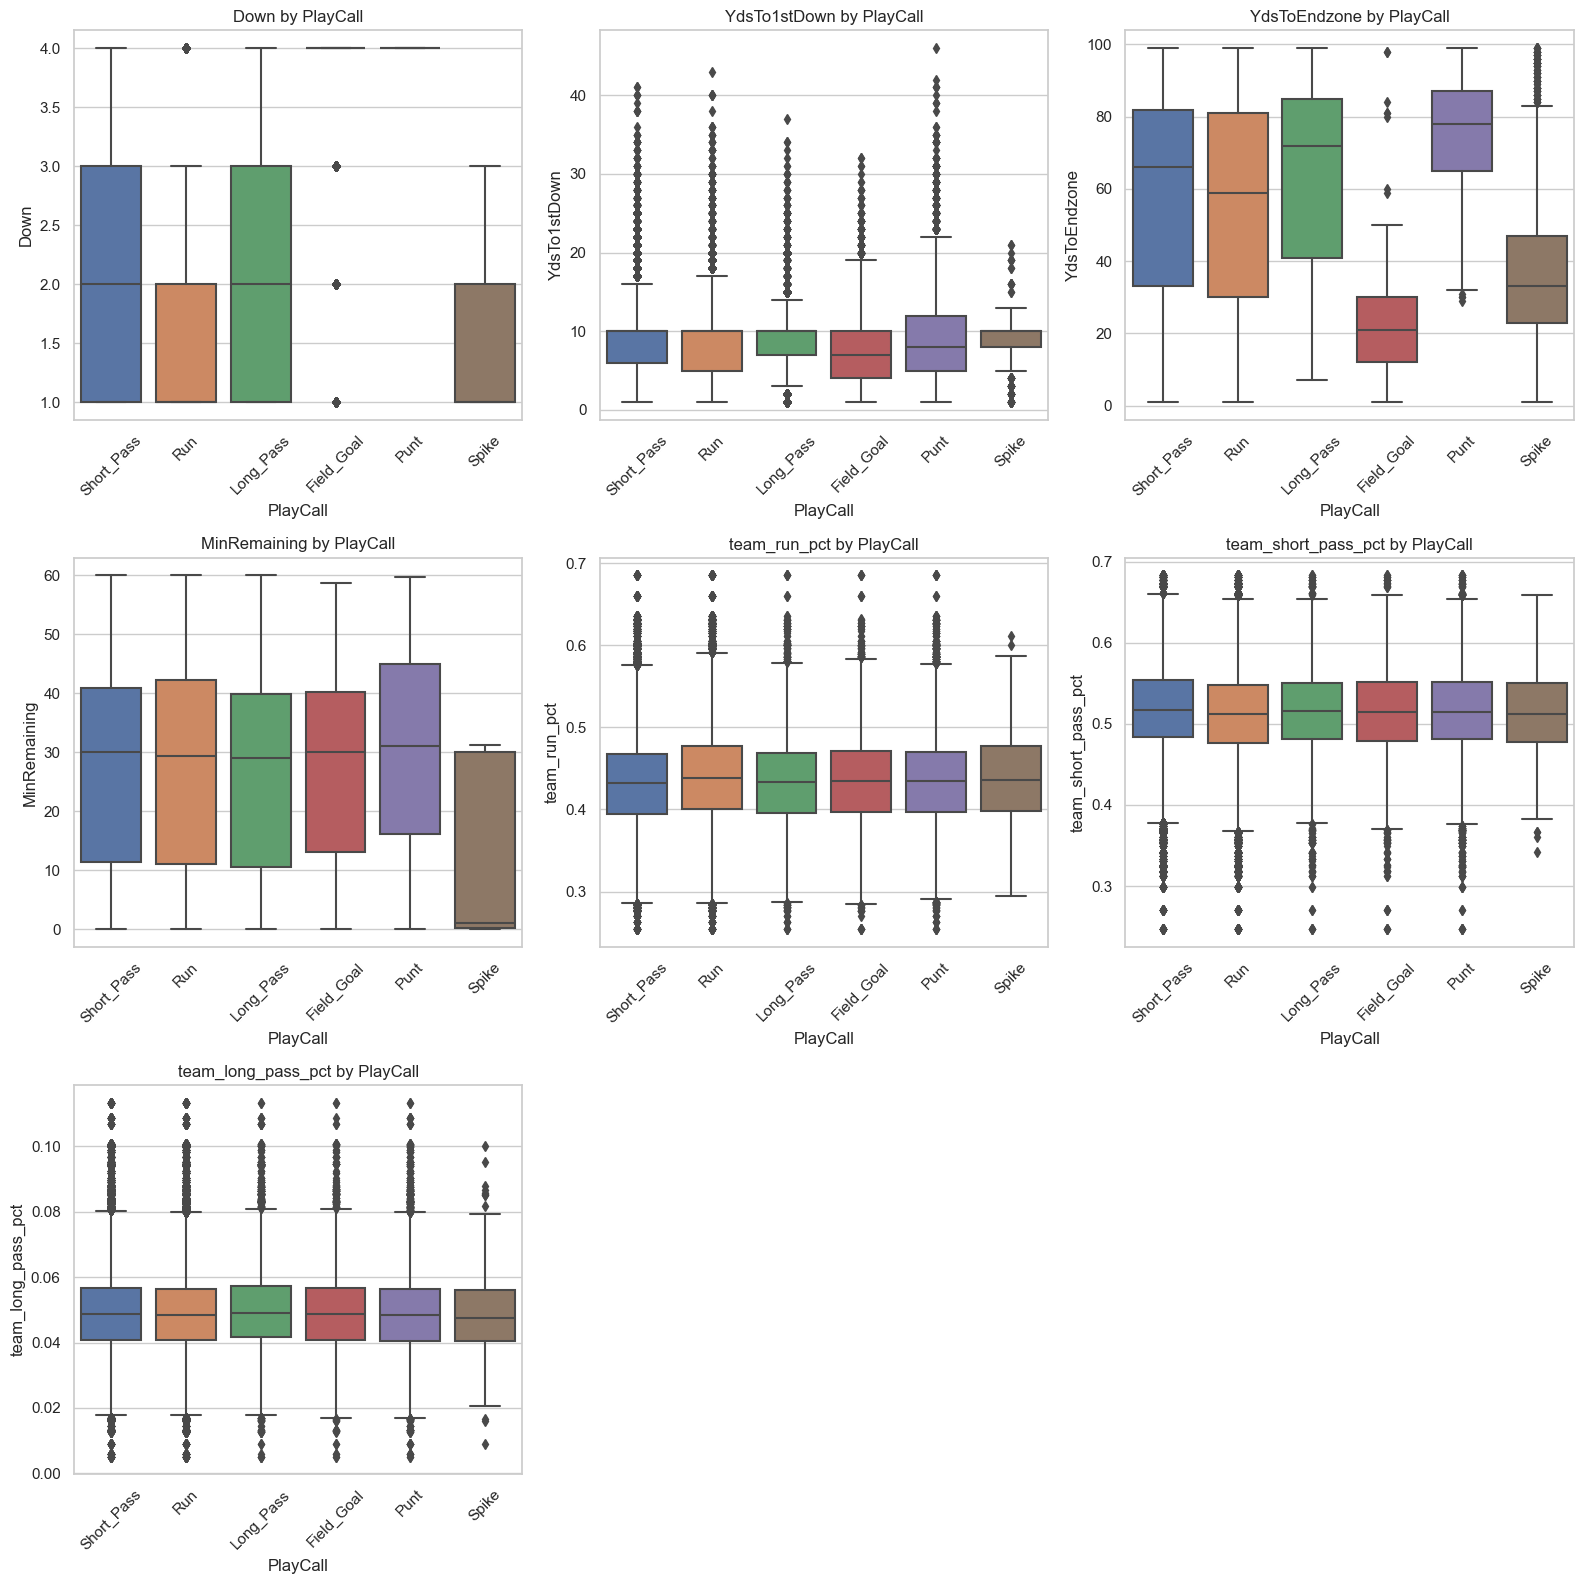

In [69]:
plt.figure(figsize=(16,16))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=clean_df, x='PlayCall', y=col)
    plt.xticks(rotation=45)
    plt.title(f"{col} by PlayCall")

plt.tight_layout()
plt.show()


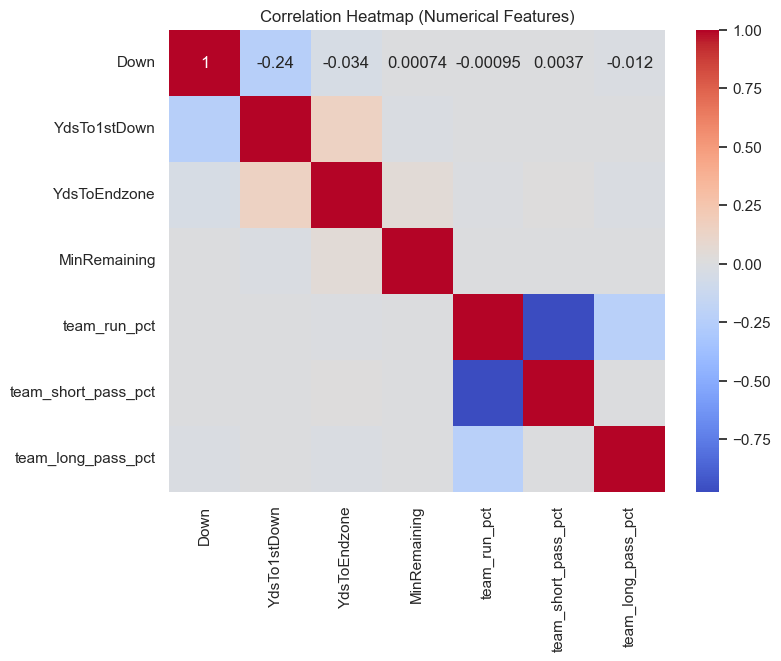

In [70]:
plt.figure(figsize=(8,6))
sns.heatmap(clean_df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

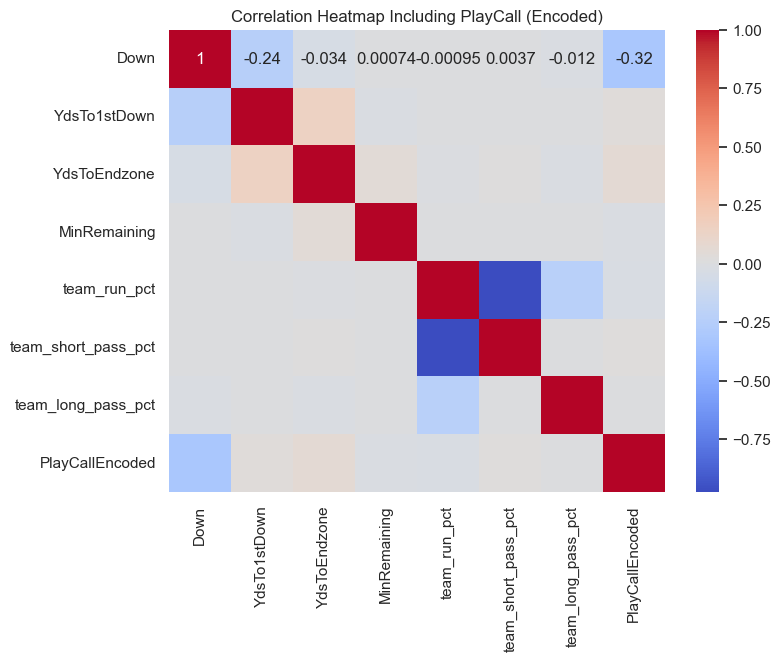

In [71]:
df_corr = clean_df.copy()
df_corr['PlayCallEncoded'] = LabelEncoder().fit_transform(df_corr['PlayCall'])

corr_matrix = df_corr[num_cols + ['PlayCallEncoded']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap Including PlayCall (Encoded)")
plt.show()

             Count  Percent
PlayCall                   
Short_Pass  132858    46.52
Run         113695    39.81
Punt         17516     6.13
Long_Pass    12600     4.41
Field_Goal    8346     2.92
Spike          573     0.20


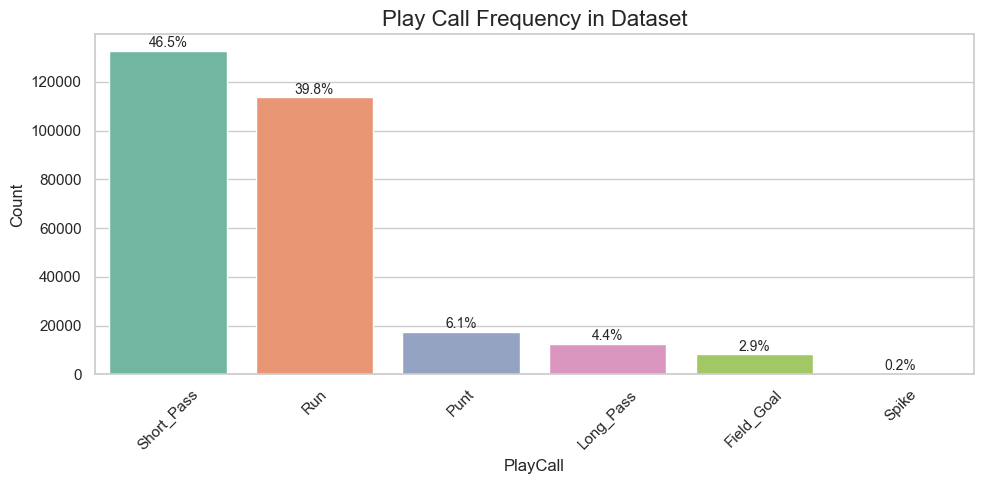

In [72]:
# count each play call
play_counts = clean_df['PlayCall'].value_counts()
play_percent = clean_df['PlayCall'].value_counts(normalize=True) * 100

# combine into a dataframe
freq_df = pd.DataFrame({
    'Count': play_counts,
    'Percent': play_percent.round(2)
})

print(freq_df)

plt.figure(figsize=(10,5))
sns.barplot(
    x=play_counts.index,
    y=play_counts.values,
    palette="Set2"
)

plt.title("Play Call Frequency in Dataset", fontsize=16)
plt.ylabel("Count")
plt.xlabel("PlayCall")
plt.xticks(rotation=45)

# annotate the bars with percentages
for i, v in enumerate(play_counts.values):
    pct = play_percent.iloc[i]
    plt.text(i, v + max(play_counts)*0.01, f"{pct:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Play Call Prediction & Testing

### Model Creation

In [73]:
sns.set(style="whitegrid")

# Features & target
feature_cols = ['Down', 'YdsTo1stDown', 'YdsToEndzone', 'MinRemaining',
                'team_run_pct', 'team_short_pass_pct', 'team_long_pass_pct']
X = clean_df[feature_cols].copy()
y = clean_df['PlayCall'].copy()

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_
print("Classes:", list(class_names))

# train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

# models definition
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(multi_class='multinomial', solver='saga', max_iter=5000, random_state=42))
    ]),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

Classes: ['Field_Goal', 'Long_Pass', 'Punt', 'Run', 'Short_Pass', 'Spike']
Train size: (214191, 7) Test size: (71397, 7)


### Model Testing & Evaluation

In [74]:
# train, predict and evaluate
results = {}
for name, model in models.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    print(f"{name} accuracy: {acc:.4f}  macro-precision: {prec:.4f}  recall: {rec:.4f}  f1: {f1:.4f}")
    print("Classification report:\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'precision_macro': prec,
        'recall_macro': rec,
        'f1_macro': f1
    }


Training LogisticRegression ...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression accuracy: 0.6074  macro-precision: 0.4720  recall: 0.4939  f1: 0.4820
Classification report:
               precision    recall  f1-score   support

  Field_Goal       0.77      0.78      0.77      2087
   Long_Pass       0.00      0.00      0.00      3150
        Punt       0.90      0.96      0.93      4379
         Run       0.55      0.64      0.59     28424
  Short_Pass       0.62      0.58      0.60     33214
       Spike       0.00      0.00      0.00       143

    accuracy                           0.61     71397
   macro avg       0.47      0.49      0.48     71397
weighted avg       0.58      0.61      0.59     71397

Confusion matrix:
 [[ 1623     0    99    71   294     0]
 [   19     0    29  1345  1757     0]
 [   22     0  4217     0   140     0]
 [  180     0   138 18295  9811     0]
 [  260     0   221 13500 19233     0]
 [    0     0     0   119    24     0]]

Training RandomForest ...
RandomForest accuracy: 0.6307  macro-precision: 0.5255  recall:

### Results Comparison

In [75]:
# comparison table
cmp_df = pd.DataFrame([
    {
        'model': name,
        'accuracy': v['accuracy'],
        'precision_macro': v['precision_macro'],
        'recall_macro': v['recall_macro'],
        'f1_macro': v['f1_macro']
    }
    for name, v in results.items()
]).set_index('model')

print("=== Model comparison (on test set) ===")
display(cmp_df)

=== Model comparison (on test set) ===


,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
LogisticRegression,0.607420,0.472007,0.493898,0.482033
RandomForest,0.630657,0.525513,0.514888,0.506041
GradientBoosting,0.646036,0.550033,0.535098,0.523045


### Feature Importances

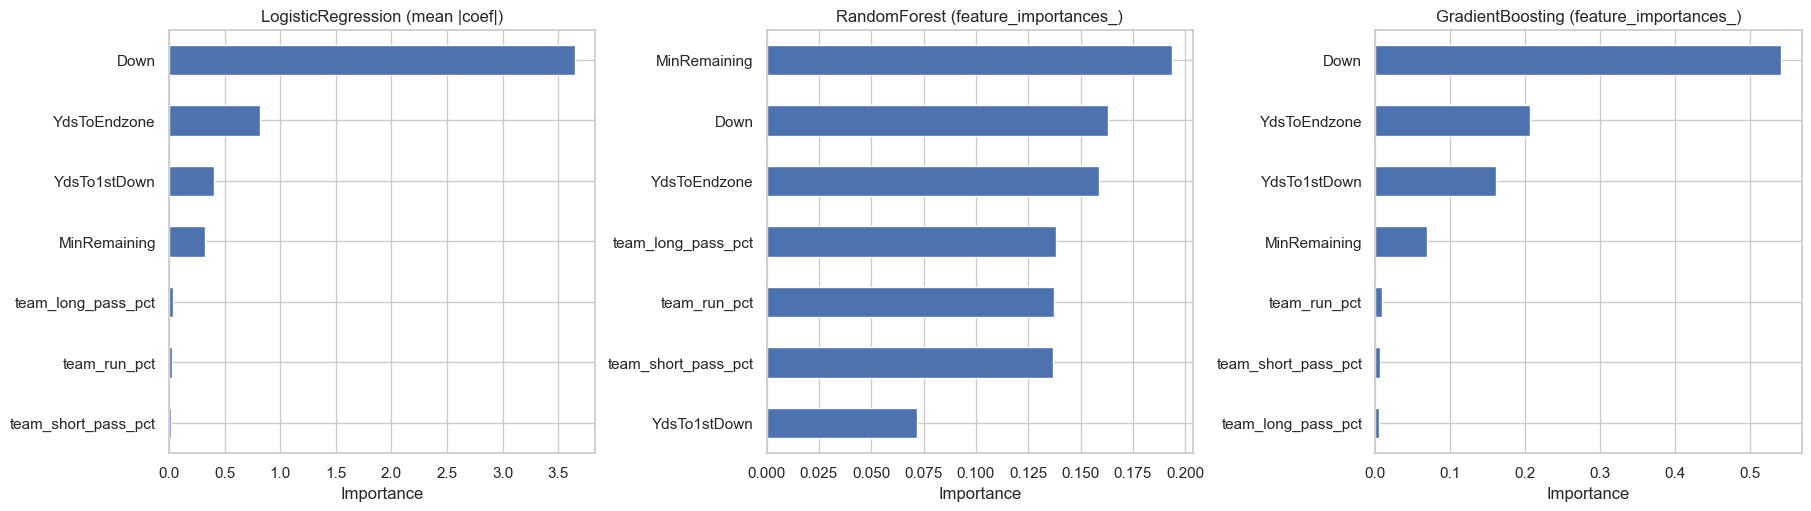

In [76]:
# feature importances
def plot_feature_importances(importances, feature_names, title, ax=None):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    if ax is None:
        plt.figure(figsize=(6,4))
        fi.plot(kind='barh')
        plt.title(title)
        plt.xlabel('Importance')
        plt.show()
    else:
        fi.plot(kind='barh', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Importance')

# get importances for each model
fig, axes = plt.subplots(1, 3, figsize=(18,5), constrained_layout=True)
for ax, (name, res) in zip(axes, results.items()):
    model = res['model']
    if name == 'LogisticRegression':
        # get coef_ from the logistic step
        clf = model.named_steps['clf']
        coefs = clf.coef_   # shape: (n_classes, n_features)
        # Use mean absolute coefficient across classes as importance
        importances = np.mean(np.abs(coefs), axis=0)
        plot_feature_importances(importances, feature_cols, title=f"{name} (mean |coef|)", ax=ax)
    elif name == 'RandomForest':
        importances = model.feature_importances_
        plot_feature_importances(importances, feature_cols, title=f"{name} (feature_importances_)", ax=ax)
    elif name == 'GradientBoosting':
        importances = model.feature_importances_
        plot_feature_importances(importances, feature_cols, title=f"{name} (feature_importances_)", ax=ax)

plt.show()

In [77]:
# top features per model in tables
for name, res in results.items():
    model = res['model']
    if name == 'LogisticRegression':
        coefs = model.named_steps['clf'].coef_
        importances = np.mean(np.abs(coefs), axis=0)
    else:
        importances = model.feature_importances_
    fi = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
    print(f"\nTop features for {name}:")
    display(fi.to_frame(name='importance').head(6))


Top features for LogisticRegression:


,importance
Down,3.651893
YdsToEndzone,0.813885
YdsTo1stDown,0.406257
MinRemaining,0.326498
team_long_pass_pct,0.035530
team_run_pct,0.020789



Top features for RandomForest:


,importance
MinRemaining,0.193904
Down,0.162939
YdsToEndzone,0.158857
team_long_pass_pct,0.138152
team_run_pct,0.137244
team_short_pass_pct,0.137050



Top features for GradientBoosting:


,importance
Down,0.542601
YdsToEndzone,0.207145
YdsTo1stDown,0.161169
MinRemaining,0.069088
team_run_pct,0.008654
team_short_pass_pct,0.006655


## Conclusion

### Ways to Improve Algorithm

### Workload Distribution